In [1]:
print("H")

H


In [2]:
# Experiment 1.2 — GraphSAGE on the Elliptic Transaction Graph
# Question: Does incorporating neighboring transactions improve illicit-transaction detection?
#
# We now build the full Elliptic graph:
#   Nodes  = transactions (203,769 total)
#   Edges  = transaction relationships (from edgelist)
#   Node features = 166 Elliptic features
#   Labels = illicit (1) / licit (0)
#
# Architecture: SAGEConv -> ReLU+Dropout -> SAGEConv -> ReLU -> Linear -> output
#
# NOTE on model class: the forward() and layer sizes here EXACTLY match
# models/bitcoin/graphsage.py (GraphSAGEModel) in the backend spec so
# the weights saved here can be loaded directly by the API server.

import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, pathlib, os

from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

c:\Users\OM MAHAJAN\miniconda3\envs\isro\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [4]:
# Load data
DATA = '../../data/elliptic_bitcoin_dataset/'

features  = pd.read_csv(DATA + 'elliptic_txs_features.csv', header=None)
classes   = pd.read_csv(DATA + 'elliptic_txs_classes.csv')
edgelist  = pd.read_csv(DATA + 'elliptic_txs_edgelist.csv')

# Column naming matches backend data_loader.py:
#   local_feat_0..93  = 94 local transaction features
#   agg_feat_0..71    = 72 aggregated neighbourhood features
features.columns = (
    ['txId', 'time_step']
    + [f'local_feat_{i}' for i in range(93)]
    + [f'agg_feat_{i}'   for i in range(72)]
)
features['txId'] = features['txId'].astype(str)

# The raw Elliptic CSV uses '1' = illicit, '2' = licit, 'unknown' = unknown
classes.columns = ['txId', 'class']
classes['txId']  = classes['txId'].astype(str)
classes['class'] = classes['class'].astype(str).map(
    {'1': 'illicit', '2': 'licit', 'unknown': 'unknown'}
)

print('Nodes (transactions):', len(features))
print('Edges               :', len(edgelist))
print('Label distribution  :')
print(classes['class'].value_counts())

Nodes (transactions): 203769
Edges               : 234355
Label distribution  :
class
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


In [5]:
# Merge features + labels
df = features.merge(classes, on='txId', how='left')
df['class'] = df['class'].fillna('unknown')
df = df.reset_index(drop=True)
tx_to_idx = {tx: idx for idx, tx in enumerate(df['txId'])}

# Labels: illicit=1, licit=0, unknown=-1 (masked out during loss computation)
label_map = {'illicit': 1, 'licit': 0, 'unknown': -1}
df['label'] = df['class'].map(label_map)

print('Label distribution after merge:')
print(df['label'].value_counts())

Label distribution after merge:
label
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64


In [6]:
# Build edge_index tensor (shape [2, num_edges])
edgelist['txId1'] = edgelist['txId1'].astype(str)
edgelist['txId2'] = edgelist['txId2'].astype(str)

src = edgelist['txId1'].map(tx_to_idx)
dst = edgelist['txId2'].map(tx_to_idx)
mask = src.notna() & dst.notna()
src = src[mask].astype(int).values
dst = dst[mask].astype(int).values

# Undirected: add both directions
edge_index = torch.tensor(
    np.stack([np.concatenate([src, dst]),
              np.concatenate([dst, src])], axis=0),
    dtype=torch.long
)
print('edge_index shape:', edge_index.shape)

edge_index shape: torch.Size([2, 468710])


In [8]:
# Node features tensor — using the same column naming as backend inference.py
FEATURE_COLS = (
    [f'local_feat_{i}' for i in range(93)]
    + [f'agg_feat_{i}'   for i in range(72)]
)
x_np = df[FEATURE_COLS].values.astype(np.float32)

# Z-score normalization
x_np = (x_np - x_np.mean(0, keepdims=True)) / (x_np.std(0, keepdims=True) + 1e-8)

x      = torch.tensor(x_np, dtype=torch.float)
labels = torch.tensor(df['label'].values, dtype=torch.long)
tsteps = torch.tensor(df['time_step'].values, dtype=torch.long)

print('Node feature tensor:', x.shape)
print('Labels tensor      :', labels.shape)

Node feature tensor: torch.Size([203769, 165])
Labels tensor      : torch.Size([203769])


In [9]:
# Temporal masks
# Train:      time steps 1-34   (labelled only)
# Validation: time steps 30-34  (labelled only, for early stopping)
# Test:       time steps 35-49  (labelled only)

labelled   = (labels >= 0)
train_mask = labelled & (tsteps >= 1)  & (tsteps <= 34)
val_mask   = labelled & (tsteps >= 30) & (tsteps <= 34)
test_mask  = labelled & (tsteps >= 35) & (tsteps <= 49)

print(f'Train: {train_mask.sum().item()}  Val: {val_mask.sum().item()}  Test: {test_mask.sum().item()}')

data = Data(x=x, edge_index=edge_index, y=labels,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
data = data.to(DEVICE)

Train: 29894  Val: 3513  Test: 16670


In [10]:
# GraphSAGE model — matches backend models/bitcoin/graphsage.py exactly
# so weights can be loaded by the API server without any changes.

class GraphSAGEModel(nn.Module):
    def __init__(self, in_channels, hidden_channels=64, out_channels=2):
        super().__init__()
        self.conv1      = SAGEConv(in_channels, hidden_channels)
        self.conv2      = SAGEConv(hidden_channels, hidden_channels)
        self.classifier = nn.Linear(hidden_channels, out_channels)
        self.dropout    = nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        return self.classifier(x)

In [11]:
# Weighted cross-entropy loss to handle class imbalance
train_labels = data.y[data.train_mask].cpu()
n_licit   = (train_labels == 0).sum().item()
n_illicit = (train_labels == 1).sum().item()
w_illicit = n_licit / n_illicit

class_weights = torch.tensor([1.0, w_illicit], dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f'Illicit class weight: {w_illicit:.2f}')

Illicit class weight: 7.63


In [13]:
# Training loop with early stopping on validation PR-AUC

model     = GraphSAGEModel(in_channels=data.x.shape[1], hidden_channels=64, out_channels=2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

MAX_EPOCHS  = 200
PATIENCE    = 20
best_val_pr = 0.0
best_state  = None
no_improve  = 0
train_losses = []

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    if epoch % 5 == 0:
        model.eval()
        with torch.no_grad():
            logits = model(data.x, data.edge_index)
            proba  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            y_val  = data.y[data.val_mask].cpu().numpy()
            p_val  = proba[data.val_mask.cpu().numpy()]
            val_pr = average_precision_score(y_val, p_val)

        if val_pr > best_val_pr:
            best_val_pr = val_pr
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1

        if no_improve >= PATIENCE // 5:
            print(f'Early stopping at epoch {epoch}. Best val PR-AUC: {best_val_pr:.4f}')
            break

    if epoch % 20 == 0:
        print(f'Epoch {epoch:03d} | Loss: {loss.item():.4f} | Best Val PR-AUC: {best_val_pr:.4f}')

model.load_state_dict(best_state)
print('Training complete.')

Epoch 020 | Loss: 0.3114 | Best Val PR-AUC: 0.7800
Epoch 040 | Loss: 0.2226 | Best Val PR-AUC: 0.9281
Epoch 060 | Loss: 0.1729 | Best Val PR-AUC: 0.9453
Epoch 080 | Loss: 0.1373 | Best Val PR-AUC: 0.9563
Epoch 100 | Loss: 0.1140 | Best Val PR-AUC: 0.9676
Epoch 120 | Loss: 0.0986 | Best Val PR-AUC: 0.9791
Epoch 140 | Loss: 0.0818 | Best Val PR-AUC: 0.9866
Epoch 160 | Loss: 0.0720 | Best Val PR-AUC: 0.9909
Epoch 180 | Loss: 0.0612 | Best Val PR-AUC: 0.9934
Epoch 200 | Loss: 0.0563 | Best Val PR-AUC: 0.9943
Training complete.


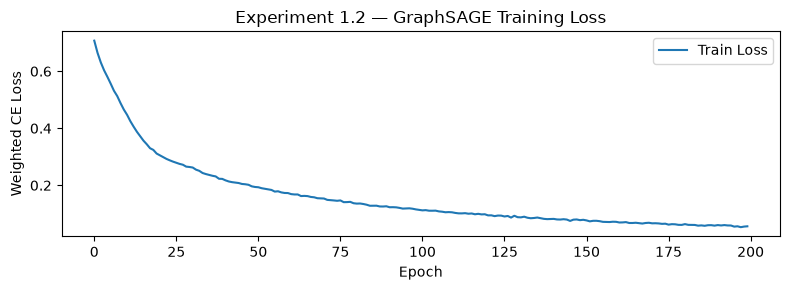

In [14]:
# Training loss plot
plt.figure(figsize=(8, 3))
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Weighted CE Loss')
plt.title('Experiment 1.2 — GraphSAGE Training Loss')
plt.legend()
plt.tight_layout()
plt.savefig('graphsage_train_loss.png', dpi=120)
plt.show()

In [15]:
# Evaluate on test set
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    proba  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
    preds  = logits.argmax(dim=1).cpu().numpy()

y_test  = data.y[data.test_mask].cpu().numpy()
p_test  = proba[data.test_mask.cpu().numpy()]
pr_test = preds[data.test_mask.cpu().numpy()]

print(classification_report(y_test, pr_test, target_names=['licit', 'illicit']))

sage_metrics = {
    'Model'    : 'GraphSAGE',
    'Accuracy' : round(accuracy_score(y_test, pr_test),          4),
    'Precision': round(precision_score(y_test, pr_test),         4),
    'Recall'   : round(recall_score(y_test, pr_test),            4),
    'F1'       : round(f1_score(y_test, pr_test),                4),
    'ROC-AUC'  : round(roc_auc_score(y_test, p_test),            4),
    'PR-AUC'   : round(average_precision_score(y_test, p_test),  4),
}
print(sage_metrics)

              precision    recall  f1-score   support

       licit       0.97      0.97      0.97     15587
     illicit       0.58      0.60      0.59      1083

    accuracy                           0.95     16670
   macro avg       0.78      0.78      0.78     16670
weighted avg       0.95      0.95      0.95     16670

{'Model': 'GraphSAGE', 'Accuracy': 0.9463, 'Precision': 0.5848, 'Recall': 0.5983, 'F1': 0.5915, 'ROC-AUC': 0.898, 'PR-AUC': 0.6162}


In [16]:
# Save results CSV for comparison in exp1.3
sage_df = pd.DataFrame([sage_metrics]).set_index('Model')
sage_df.to_csv('graphsage_results.csv')

if os.path.exists('baseline_ml_results.csv'):
    baseline = pd.read_csv('baseline_ml_results.csv', index_col='Model')
    comparison = pd.concat([baseline, sage_df])
    print('Comparison so far:')
    print(comparison.to_string())
else:
    print('Run exp1.1 first to see full comparison. GraphSAGE results:')
    print(sage_df.to_string())

Comparison so far:
                     Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                    
Logistic Regression    0.7537     0.1919  0.8689  0.3143   0.8864  0.2791
Random Forest          0.9771     0.9053  0.7239  0.8045   0.9406  0.7986
GraphSAGE              0.9463     0.5848  0.5983  0.5915   0.8980  0.6162


In [17]:
# Save weights with the filename the backend expects: graphsage_best.pt
# Copy this file to backend/weights/graphsage_best.pt before starting the API server.
torch.save(model.state_dict(), 'graphsage_best.pt')
print('Weights saved to graphsage_best.pt  (-> copy to backend/weights/graphsage_best.pt)')

# Also write a partial bitcoin_metrics.json that exp1.3 will complete
# The backend reads precomputed/bitcoin_metrics.json to serve /api/bitcoin/metrics
metrics_json = {
    'graphsage': {
        'accuracy' : sage_metrics['Accuracy'],
        'precision': sage_metrics['Precision'],
        'recall'   : sage_metrics['Recall'],
        'f1'       : sage_metrics['F1'],
        'roc_auc'  : sage_metrics['ROC-AUC'],
        'pr_auc'   : sage_metrics['PR-AUC'],
    }
}
with open('bitcoin_metrics_partial.json', 'w') as f:
    json.dump(metrics_json, f, indent=2)
print('Partial metrics JSON saved. exp1.3 will add GAT results and write the final file.')

# OBSERVATION
# GraphSAGE uses neighbourhood aggregation to incorporate the transaction graph structure.
# Each node's representation is updated by aggregating its neighbours' features,
# which lets the model detect patterns that span across connected transactions.
#
# However, GraphSAGE aggregates all neighbours with EQUAL weight.
# It cannot automatically learn which neighbouring transactions are more informative.
#
# This motivates GAT (exp1.3), which adds learned attention weights over neighbours.
print('Experiment 1.2 done.')

Weights saved to graphsage_best.pt  (-> copy to backend/weights/graphsage_best.pt)
Partial metrics JSON saved. exp1.3 will add GAT results and write the final file.
Experiment 1.2 done.
